![](https://drive.google.com/uc?export=view&id=1dXA0Ac-6jYiuCGWpVq8pTpnl01vQadR5)*„Akademia Innowacyjnych Zastosowań Technologii Cyfrowych (AI Tech)”,
projekt finansowany ze środków Programu Operacyjnego Polska Cyfrowa POPC.03.02.00-00-0001/20*



---

**Przedmiot:** Uczenie Głębokie<br>
**Moduł:** 2 (Podstawy Głębokiego Uczenia)<br>
**Laboratoria:** 2<br>
**Opis laboratoriów:** Zajęcia wprowadzające w tematykę głębokiego uczenia. Materiał poruszany na zajęciach obejmuje teoretyczne podstawy działania głębokich sieci neuronowych oraz kluczowe aspekty skutecznego wykorzystania modeli neuronowych w praktycznych zastosowaniach.

---

# Materiały właściwe

## Polecana litertura

- Ian Goodfellow, Yoshua Bengio, Aaron Courville. _Deep learning_, MIT Press, 2016. [www.deeplearningbook.org](https://www.deeplearningbook.org)
- Aston Zhang, Zachary C. Lipton, Mu Li, Alexander J. Smola. _Dive into Deep Learning: Interactive deep learning book with code, math, and discussions_. [d2l.ai](https://d2l.ai)



## Wprowadzenie teoretyczne

### Funkcje Pomocnicze

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_inline.backend_inline import set_matplotlib_formats


%matplotlib inline
set_matplotlib_formats('svg')
plt.rcParams['figure.figsize'] = [11, 5]
sns.set_theme()

### Wsteczna propagacja błędu

Podstawowym elementem każdej sieci neuronowej jest **sztuczny neuron**. Jest to jednostka która wykonuje następującą operację:

$$z = \sum_i x_i * w_i + b$$
$$y = f(z)$$

Gdzie $x_i$ to i-te *wejście* perceptronu, $w_i$ to waga przypisana do tego wejścia, natomiast $b$ to pewna stała (ang. _bias_). Wyjście funkcji liniowej $z$ jest następnie podawane na wejście pewnej funkcji aktywacji $f$, która generuje ostateczne wyjście neuronu $y$.

Istnieje wiele funkcji aktywacji takich jak:
* skokowa (*funkcja progowa unipolarna*),
$${\displaystyle y(x)=\left\{{\begin{matrix}0 & dla & x\lt a\\1 & dla&x\geq a\\\end{matrix}}\right.}$$
* sigmoid,
$$y(x)={\frac {1}{1+e^{-\beta x}}}$$
* tangens hiperboliczny,
$$y(x)={\frac {2}{1+e^{-\beta x}}}-1={\frac {1-e^{-\beta x}}{1+e^{-\beta x}}}$$
* ReLU (Rectified Linear Unit),
$$y(x)=max(0, x)$$


 Dla skokowej funkcji aktywacji zwyczajowo mówimy o perceptronie, dla innych funkcji aktywacji mówimy o **neuronie**.

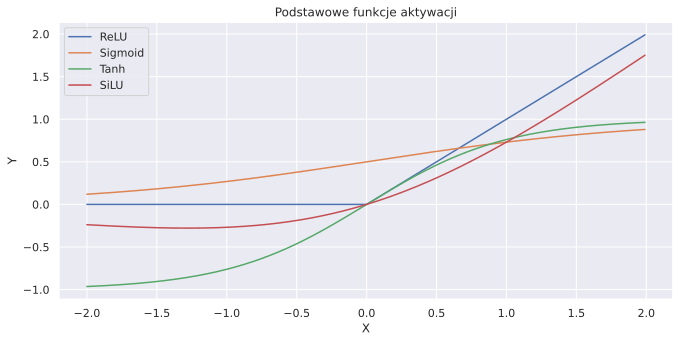

In [ ]:
x = torch.arange(-2, 2, 0.01)

plt.plot(x, F.relu(x), label='ReLU')
plt.plot(x, torch.sigmoid(x), label='sigmoid')
plt.plot(x, torch.tanh(x), label='tanh')
plt.plot(x, F.silu(x), label='SiLU')
plt.legend()
plt.title('Podstawowe funkcje aktywacji')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

---

Neuron wchodzi w skład wielu różnych elementów sieci neuronowej jak **warstwa w pełni połączona** (ang. _fully connected layer_ lub _dense layer_) czy warstwa konwolucyjna.

W przypadku warstwy fully connected wzór rozszerza się trywialnie na:

$$z_j = \sum_i x_i * w_{ij} + b_j$$
$$y_j = f(z_j)$$

Gdzie $j$ oznacza $j$-ty neuron.
Jak widać powyżej, każdy z neuronów korzysta ze wszystkich wejść. Składnik $\sum_i x_i * w_{ij}$ to kombinacja liniowa.

---

W praktyce, dla wydajności obliczeniowej, operacje dla całej warstwy wykonuje się jednocześnie. Powyższe równania dla wszystkich neuronów w warstwie można zapisać w zwartej formie macierzowej:

$$\mathbf{z} = \mathbf{W}\mathbf{x} + \mathbf{b}$$
$$\mathbf{y} = f(\mathbf{z})$$

In [ ]:
# x = torch.rand(1, 1)
x = torch.tensor([[0.5]])

w = torch.ones(1, 2)
b = torch.ones(2)

z = x @ w + b
y = F.relu(z)

print('Zmienne uczone:')
print('w:', w.numpy())
print('b:', b.numpy(), '\n')

print('Wejście neuronu:')
print('x:', x.numpy(), '\n')

print('Pobudzenie neuronu:')
print('z:', z.numpy(), '\n')

print('wyjście neuronu:')
print('y:', y.numpy())

Zmienne uczone:
w: [[1. 1.]]
b: [1. 1.] 

Wejście neuronu:
x: [[0.5]] 

Pobudzenie neuronu:
z: [[1.5 1.5]] 

wyjście neuronu:
y: [[1.5 1.5]]


---

Celem **uczenia sieci neuronowej** jest dostrojenie jej parametrów w taki sposób, aby jak najdokładniej realizowała określone zadanie (np. klasyfikację obrazów). Kluczowym elementem tego procesu jest **funkcja straty** (ang. _loss function_), a konkretnie jej minimalizacja.

Funkcja straty określa jak bardzo nasza sieć myli się na danym przykładzie. Przykładowo, jeśli neuron ma za zadanie odwzorować funkcję sinus, to funkcją straty może być różnica pomiędzy estymowanym wyjściem neuronu ($y$) a pożądanym wyjściem ($y'$). Innym przykładem może być klasyfikacja - sieć może estymować rozkład prawdopodobieństwa klas dla danego obrazka wejściowego (np. czy jest to kot czy pies), natomiast pożądanym wyjściem będzie wektor **one-hot** (kodowanie 1 z n) z zapalonym bitem na pozycji klasy prawdziwej. Wówczas jako funkcję straty możemy wykorzystać **cross-entropy**.

Dla różnego rodzaju sieci (i ich przeznczenia) można korzystać z różnych funkcji strat. Do najpopularniejszych należą:

- **Mean Square Error** (MSE, błąd średniokwadratowy):
$$L = \frac{1}{n}\sum_i^n(y_i - y_i')^2$$
gdzie $y_i$ to wyjście z neuronu (sieci) dla $i$-tej próbki, natomiast $y_i'$ to tzw. _ground-truth_ - wartość, którą neuron (sieć) ma aproksymować,
- **Mean Absolute Error** (MAE, średni błąd bezwzględny):
$$L = \frac{1}{n}\sum_i^n |y_i - y_i'|$$
- **Cross-Entropy** (entropia krzyżowa):
$$L(p,q) = -\sum _{x}p(x)\,\log q(x)$$
gdzie $p$ to pewien rozkład prawdopodobieństwa estymowany przez sieć, $q$ to _ground-truth_ rozkład prawdopodobieństwa, a $x$ to przykład wejściowy.

In [ ]:
y_true = torch.tensor([[5., 1.]])

L = torch.mean((y - y_true) ** 2, dim=-1)
# lub
# L = F.mse_loss(y, y_true)

print('Błąd średniokwadratowy:')
print('L:', L.numpy())

Błąd średniokwadratowy:
L: [6.25]


---

W działaniu sieci neuronowej można wyróżnić **zmienne uczące** (**parametry**, **wagi**) oraz **propagowany sygnał**. Zmiennymi uczącymi nazywamy wszystkie parametry, które wchodzą w skład neuronów ale nie są podawane na wejściu. Z ich pomocą uczymy sieć aby produkowała pożądane wyjście na podstawie przykładów wejściowych. Przykłady wejściowe jak i rezultaty neuronów nazywamy propagowanym sygnałem. Jest to sygnał wykorzystany w procesie uczenia do określenia błędu jaki popełnił każdy z neuronów i w końcu do **obliczenia nowych wartości zmiennych**.

Jak wspomniano wcześniej, proces uczenia polega na minimalizacji funkcji straty $L$. Osiągamy to poprzez iteracyjną modyfikację zmiennych uczących. Najpopularniejszym algorytmem służącym do tego celu jest algorytm spadku wzdłuż gradientu (ang. _gradient descent_) lub jego rozwinięcia.
Aby zmniejszyć wartość funkcji straty, musimy modyfikować parametry sieci w kierunku "największego spadku" tej funkcji. Ten kierunek jest wyznaczany przez gradient funkcji straty.Wyliczenie nowych wartości zmiennych przebiega zgodnie z zasadą:

$$w_i' = w_i - \mu \frac{\partial L}{\partial w_i} $$

Gdzie $\mu$ to prędkość uczenia ($\mu$ czyta się "mi").

Jak widać największy problem stanowi obliczenie pochodnej funkcji straty po danej wadze. W przypadku <ins>jednowarstwowej</ins> sieci neuronowej korzystając reguły łańcuchowej (_chain rule_) otrzymujemy:

$$\frac{\partial L}{\partial w_i} = \frac{\partial L}{\partial y} \frac{\partial y}{\partial w_i}$$

Wówczas ponownie korzystając z _chain rule_:

$$\frac{\partial L}{\partial w_i} = \frac{\partial L}{\partial y} \frac{\partial y}{\partial w_i} = \frac{\partial L}{\partial y} \frac{\partial y}{\partial z}\frac{\partial z}{\partial w_i}$$

Gdzie $\frac{\partial y}{\partial z}$ to pochodna funkcji aktywacji, natomiast $z = \sum_iw_ix_i + b$, dla której pochodna jest równa $x_i$, stąd:

$$\frac{\partial L}{\partial w_i} = \frac{\partial L}{\partial y} f'(z) x_i$$

Końcowo:

$$w_i' = w_i - \mu \frac{\partial L}{\partial y} f'(z) x_i $$

*Wskazówka:*

* Zastępując $\frac{\partial L}{\partial y} f'(z) = \delta$ wzór można zapisać jako:
$$w_i' = w_i - \mu \delta x_i $$

In [ ]:
num_outputs = y.shape[1]
dl_dy = 2.0 / num_outputs * (y - y_true)
dy_dz = (z > 0).to(torch.float32)
dz_dw = x

print('Pochodne cząstkowe:')
print('dL/dy:', dl_dy.numpy())
print('dy/dz:', dy_dz.numpy())
print('dz/dw:', dz_dw.numpy())

Pochodne cząstkowe:
dL/dy: [[-3.5  0.5]]
dy/dz: [[1. 1.]]
dz/dw: [[0.5]]


In [ ]:
dL_dw =  dl_dy * dy_dz * dz_dw

print('Pochodna końcowa:', dL_dw.numpy())

Pochodna końcowa: [[-1.75  0.25]]


In [ ]:
new_w = w - 0.01 * dL_dw

print('Zmienna po aktualizacji wag:', new_w.numpy())

Zmienna po aktualizacji wag: [[1.0175 0.9975]]


**Dodatek: Weryfikacja za pomocą automatycznego różniczkowania (_autograd_)**

In [ ]:
# Włączone śledzeniem gradientów (requires_grad)
w_auto = torch.ones(1, 2, requires_grad=True)
b_auto = torch.ones(2, requires_grad=True)

z_auto = x @ w_auto + b_auto
z_auto.retain_grad()

y_auto = F.relu(z_auto)

loss = F.mse_loss(y_auto, y_true)

# Automatyczne obliczanie gradientów
loss.backward()


dl_dz = dl_dy * dy_dz
print('dL/dz (ręcznie) :', dl_dz.numpy())
print('dL/dz (autograd): ', z_auto.grad.numpy(), '\n')

dl_dw = dl_dz * dz_dw
print('dL/dw (ręcznie) :', dl_dw.numpy())
print('dL/dw (autograd): ', w_auto.grad.numpy())

dL/dz (ręcznie) : [[-3.5  0.5]]
dL/dz (autograd):  [[-3.5  0.5]] 

dL/dw (ręcznie) : [[-1.75  0.25]]
dL/dw (autograd):  [[-1.75  0.25]]


---
**Algorytm wstecznej propagacji błędu (backpropagation)**

Do wyprowadzenia wzorów na aktualizację zmiennych w algorytmie niezbędna jest znajomość zagadnień **chain-rule** oraz **multivariable chain-rule**. Poza podstawową wiedzą z matematyki są to jedyne niezbędne zagadnienia.

**Chain-rule & Multivariable Chain-rule**

Poniżej zostały zaprezentowane zagadnienia **chain-rule** oraz **multivariable chain-rule** w sposób intuicyjny (i graficzny). Poniższa notacja została zaczerpnięta z sieci neuronowych, aby skojarzyć związek z algorytmem **backpropagation**.

**Chain-rule**

Jest to reguła opierająca się na pochodnej funkcji złożonej. W graficzny sposób można to pokazać następująco:

![chain-rule](https://drive.google.com/uc?id=1S8pSUrrOzoisKr8d8YJaQHNLYgEq2dpk)

Gdzie $L$ to pewna funkcja dla której liczymy pochodną względem zmiennej $w$. Jak widać, $L$ zależy od $y$, który zależy od $z$ który dopiero zależy bezpośrednio od $w$. Zależności tworzą łańcuch, skąd pochodzi nazwa **chain-rule**.

**Multivariable Chain-rule**

W przypadku gdy "łańcuch" w pewnym momencie się rozgałęzia, dalej możemy korzystać z zasady **chain-rule**, jednak tym razem przybiera ona formę nieco inną (lecz dalej intuicyjną):

![multivariable-chain-rule](https://drive.google.com/uc?id=13WH6JXd_5rnTkyToKrBcCZDPdUXCqoT8)

W tym przypadku, pochodna funkcji $L$ po zmiennej $z$ wyrażona jest jako suma pochodnych funkcji złożonych odpowiednio $y_1$ oraz $y_2$.

**Backpropagation**

Algorytm **wstecznej propagacji błędu** jest właściwie jedynie rozwinięciem **reguły delta**, która została przedstawiona wcześniej. Podobnie jak poprzednio, uczenie neuronów opisane jest w następujący sposób:

$$w_i' = w_i - \mu \frac{\partial L}{\partial w_i} $$

Jedyną różnicą jest sposób w jaki się wylicza gradient. Nawiązując do powyższych, krótkich wyjaśnień **chain-rule**, w podobny sposób należy traktować sieci neuronowe.

**Dla warstwy wyjściowej** gradient można przedstawić następująco:

$$\frac{\partial L}{\partial w_{ij}} = \frac{\partial L}{\partial y_j} \frac{\partial y_j}{\partial w_{ji}} = \frac{\partial L}{\partial y_j} \frac{\partial y_j}{\partial z_j}\frac{\partial z_j}{\partial w_{ji}}$$

Albo inaczej:

$$\frac{\partial L}{\partial w_{ij}} = \delta_j o_i$$

Gdzie $w_{ji}$ oznacza wagę połączenia pomiędzy neuronem $j$ a $i$, $\delta_j = \frac{\partial L}{\partial y_j} \frac{\partial y_j}{\partial z_j}$ oraz $o_i$ to wyjście z neuronu $i$ (dla neuronów w pierwszej warstwie będą to wejścia do sieci, natomiast w kolejnych warstwach będą to wyjścia z neuronów poprzednich).

In [ ]:
x = torch.rand(1, 5)

w = torch.ones(5, 2)
b = torch.ones(2)

z = x @ w + b
y = F.relu(z)

y_true = torch.tensor([[5., 1.]])

L = torch.mean((y - y_true) ** 2, dim=-1)

dl_dy = 2.0 / y.shape[1] * (y - y_true)
dy_dz = (z > 0).float()
dz_dw = x

print('Pochodne cząstkowe:')
print('dL/dy:', dl_dy.numpy())
print('dy/dz:', dy_dz.numpy())
print('dz/dw:', dz_dw.numpy())

Pochodne cząstkowe:
dL/dy: [[-1.2599633  2.7400367]]
dy/dz: [[1. 1.]]
dz/dw: [[0.46704996 0.8406051  0.08681303 0.514823   0.83074564]]


In [ ]:
# Inna kolejność i inne operacje !!!
dl_dw = dz_dw.T @ dl_dz

print('Pochodna końcowa:', dl_dw.numpy())

Pochodna końcowa: [[-1.6346748   0.23352498]
 [-2.9421177   0.42030254]
 [-0.3038456   0.04340652]
 [-1.8018806   0.2574115 ]
 [-2.9076097   0.41537282]]


In [ ]:
new_w = w - 0.01 * dl_dw

print('Zmienna po aktualizacji wag:\n', new_w.numpy())

Zmienna po aktualizacji wag:
 [[1.0163467  0.99766475]
 [1.0294212  0.995797  ]
 [1.0030384  0.99956596]
 [1.0180188  0.9974259 ]
 [1.0290761  0.9958463 ]]


---

**Dla warstwy ukrytej** sprawa nieco bardziej się komplikuje. Weźmy jako przykład następującą prostą sieć z 2 warstwami i łącznie 3 neuronami:

![simplenet](https://drive.google.com/uc?id=1NXHjEWUX3gAbn8NnHh9eGWdQaSNDavKW)

Dla warstwy wyjściowej możemy skorzystać jedynie z **chain-rule** uzyskując następujące równanie (indeks górny $...^2$ oznacza tutaj indeks warstwy):

$$\frac{\partial L}{\partial w^{2}_{i}} = \frac{\partial L}{\partial y^{2}_i} \frac{\partial y^{2}_i}{\partial z^{2}_i}\frac{\partial z^{2}_i}{\partial w^{2}_{i}} = \delta^2_i y^1_1$$

Przy obliczaniu gradientu dla warstwy ukrytej najpierw stosujemy  proste **chain-rule**:

$$\frac{\partial L}{\partial w^{1}_{1}} = \frac{\partial L}{\partial y^{1}_1} \frac{\partial y^{1}_1}{\partial z^{1}_1}\frac{\partial z^{1}_1}{\partial w^{1}_{1}}$$

W tym momencie można zauważyć, że jest możliwe zastosowanie **multivariable chain-rule** do wyrażenia $\frac{\partial L}{\partial y^{1}_1}$ (ponieważ $L$ nie zależy bezpośrednio od $y^{1}_1$, oraz występuje "rozgałęzienie" od $y$):

$$\frac{\partial L}{\partial y^{1}_1} = \frac{\partial L}{\partial y^{2}_1} \frac{\partial y^{2}_1}{\partial y^{1}_1} + \frac{\partial L}{\partial y^{2}_2} \frac{\partial y^{2}_2}{\partial y^{1}_1} = \frac{\partial L}{\partial y^{2}_1} \frac{\partial y^{2}_1}{\partial z^{2}_1}\frac{\partial z^{2}_1}{\partial y^{1}_1} + \frac{\partial L}{\partial y^{2}_2} \frac{\partial y^{2}_2}{\partial z^{2}_2} \frac{\partial z^{2}_2}{\partial y^{1}_1}$$

Tu można zauważyć, że $\frac{\partial z^{2}_2}{\partial y^{1}_1} = w^2_2$ oraz $\frac{\partial L}{\partial y^{2}_2} \frac{\partial y^{2}_2}{\partial z^{2}_2} = \delta^2_2$ (przy założeniu liniowej funkcji aktywacji), co daje nam końcowo:

$$\frac{\partial L}{\partial y^{1}_1} = \sum_i^2 \delta^2_i w^2_i$$

Podstawiając do wcześniejszego wzoru otrzymujemy:

$$\frac{\partial L}{\partial w^{1}_{1}} = \sum_i^2 \delta^2_i w^2_i \frac{\partial y^{1}_1}{\partial z^{1}_1}\frac{\partial z^{1}_1}{\partial w^{1}_{1}}$$

Ostatecznie, za pomocą następujących podstawień możemy sprowadzić powyższe równanie do wersji spójnej z gradientem dla warstwy wyjściowej:

$$\sum_i^2 \delta^2_i w^2_i \frac{\partial y^{1}_1}{\partial z^{1}_1} = \delta^1_1$$
$$\frac{\partial z^{1}_1}{\partial w^{1}_{1}} = x$$
$$\frac{\partial L}{\partial w^{1}_{1}} = \delta^1_1 x$$

---

Podsumowując, zarówno dla warstwy wyjściowej jak i warstwy ukrytej gradienty możemy przedstawić w tej samej formie, składającej się z **błędu neuronu** ($\delta$), oraz wyjścia z poprzedniej warstwy ($y$ lub $x$).

$$\frac{\partial L}{\partial w^{i}_{j}} = \delta^i_j o^{(i-1)}$$

### Wykres funkcji straty


W większości przypadków przedstawienie wykresu funkcji straty jest niemożliwe ze względu na zależność od wszystkich zmiennych uczonych modelu neuronowego. Łatwo jednak przedstawić problem optymalizacji względem funkcji straty na podstawie sieci neuronowej która ma dokładnie jedną zmienną uczoną.

Poniższy przykład przedstawia wykres funkcji straty dla jednoparametrowej sieci neuronowej której zadanie polega na estymacji funkcji kwadratowej o współczynniku kierunkowym 1, bez przesunięcia liniowego.

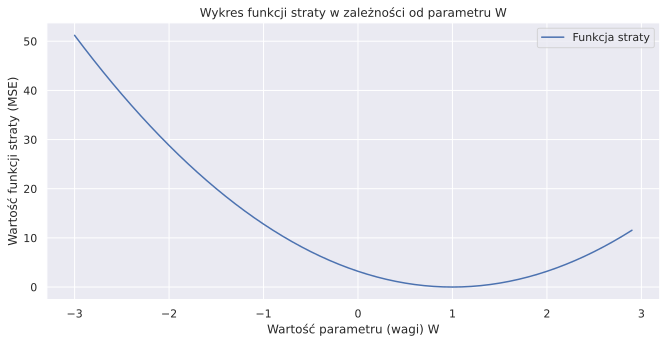

In [ ]:
x = torch.arange(-2, 2, 0.01)
y_true = x ** 2

def network(x, w):
    return w * x ** 2

W = torch.arange(-3, 3, 0.1)
L = [torch.mean((network(x, w) - y_true) ** 2) for w in W]

plt.plot(W, L, label='Funkcja straty')
plt.legend()
plt.title('Wykres funkcji straty w zależności od parametru W')
plt.xlabel('Wartość parametru (wagi) W')
plt.ylabel('Wartość funkcji straty (MSE)')
plt.show()

Powyższy wykres można graficznie interpretować następująco: **funkcja straty osiągnie minimum globalne dla zmiennej uczonej o wartości 1**. Wartość 1 można znaleźć na wiele sposobów: graficznie, wsteczną propagacją błędu, metodami optymalizacji, metodami genetycznymi, itp.

Ciekawe uzupełnienie:
 - [Youtube](https://youtu.be/RP0JScZG6gA?si=EI4FiiTXDgL18dQ3) lub [pdf](https://courses.d2l.ai/berkeley-stat-157/slides/1_29/3-Gradient.pdf) (Berkeley STAT 157 Unit 3: Gradients, Chain Rule, Automatic Differentiation)

## Przykładowe pytania sprawdzające wiedzę

### Pytanie 1

**Dlaczego uczenie metodą największego spadku działa dla głębokich sieci neuronowych?**

- *Wytłumacz podpierając się wiedzą na temat algorytmu wstecznej propagacji błędu i reguły łańcuchowej,*

### Pytanie 2

**Gradient Descent kontra Stochastic Gradient Descent. Czym się różnią od siebie i kiedy warto je stosować?**

### Pytanie 3

**Scharakteryzuj przeuczenie i niedouczenie sieci neuronowych (kiedy zachodzi, jaka jest przyczyna, jak można je zniwelować).**

- *Curse of Dimensionality*

### Pytanie 4

**Czym jest epoka, batch i iteracja?**

- *Opisz pełną pętlę uczenia*

### Pytanie 5

**Czym różnią się od siebie zbiory: treningowy, walidacyjny i testowy?**

### Pytanie 6

- **Czym jest zanik gradientu a czym jest wybuch gradientu?**
- **Kiedy występuje zanik i wybuch gradientu (odpowiedz podpierając się wiedzą na temat algorytmu wstecznej propagacji błędu).**

### Pytanie 7

- **Jakie są główne działy uczenia głębokiego (oraz ogólnie uczenia maszynowego)?**
- **Wymień po trzy przykłady z każdego działu.**

### Pytanie 8

**Do czego służą Batch Normalization i Layer Normalization, jak działają i jaka jest między nimi różnica?**

- *Jaka działają podczas treningu, a jak podczas inferencji?*
- *Kiedy nie warto korzystać z Batch Normalization*

### Pytanie 9

**Jak działa i do czego służy Dropout?**

*Jaka działa podczas treningu, a jak podczas inferencji?*

### Pytanie 10
**Corelation vs Causation (korelacja kontra przyczynowość). Jaka jest różnica i odkrycie których z nich jest celem sztucznej inteligencji.**

### Pytania o modele

 - drzewa decyzyjne (!): warunek dzielenia, algorytmy tworzenia, przykładowa inferencja,
 - transformery: poprzedniki transformerów, przykładowe architektury, przykładowe zastosowania, czym jest attention, czym jest self attention,
 - gany: ogólny schemat, zastosowanie, przykładowe architektury, typ uczenia (!),
 - r-cnn, fast r-cnn, faster r-cnn - jak działa, co to RoI, czym jest IoU, architektura, kolejne etapy doskonalenia modelu,
 - mask r-cnn - na czym sie opiera, jak wygląda wyjście z modelu, czym różni się od faster r-cnn,
 - YOLO - pytania jak w faster r-cnn,
 - sieci rekurencyjne (Hopfield, GRU, LSTM - co likwidują, ile mają bramek wewnętrznych)